In [2]:
#This is my random forest algorithm
import yfinance as yf 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [3]:
def is_real_ticker(ticker):
    Stock = yf.Ticker(ticker)
    data = Stock.history(period="1d")
    return not data.empty

#This code will ensure that the ticker inputted is real by checking 
#if the stock has historical data.

Stock = input("Enter a Stock Ticker:")

if not is_real_ticker(Stock):
    print("Invalid Stock Ticker. Please try again.")
    exit()

#If no data is found it will print an error message and exit the program.

    
data = yf.download(Stock, start="2016-01-01", end=datetime.now().strftime("%Y-%m-%d"))

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)

#Fixed a multi-index issue that came from downloading data from yfinance
#It checks if there are multiple columns and removes the unnecessary column. Being column number 1.

data['Return'] = data['Close'].pct_change()

#The return calculates as the percentage change of the closing price.

data['Target'] = (data["Return"].shift(-1) > 0 ).astype(int)

#The target is calculated by checking if the return is positive(1) or negative(0).

data['Return_lag1'] = data['Return'].shift(1)
data['Return_lag2'] = data['Return'].shift(2)
data['Return_lag5'] = data['Return'].shift(5)
data['Return_lag10'] = data['Return'].shift(10)

#These lag featurs shift the return column moving the data down 
#so the today column is now yesterdays return and so on.

data['MA5'] = data['Close'].rolling(5).mean()
data['MA10'] = data['Close'].rolling(10).mean()

#This calculates the moving average of the closing price over the last 5 and 10 days.

data['Volatility'] = data['Return'].rolling(10).std()

#This Volatility feature calculates the standard deviation of the return last ten days.

data["Price_MA5"] = (data["Close"] - data["MA5"])/ data["MA5"]

#This feature calculates the price relative to the 5-day moving average

data["Volume_change"] = data["Volume"].pct_change()

#This feature calculates the percentage change in volume.

data["Overnight_Gap"] = (data['Open'] - data['Close'].shift(1)) / data['Close'].shift(1)

#This Overnight Gap feature calculates the change 
#between the previous day close and the current day open.

data["Ratio_20MA"] = data['Close'] / data['Close'].rolling(window=20).mean()

#This ratio calculates the current closing price relative to the 20-day moving average.

data["Dist-10H"] = (data['High'].rolling(window=10).max() - data['Close']) / data['Close']

#This calculation is the distance between the current closing price 
#and the highest price over the last 10 days

data["AvgVOL-5"] = (data['Volume_change']- data['Volume_change'].rolling(5).mean()) / data['Volume_change'].rolling(5).mean()

#This feature calculates the Average volume change over the last 5 days 

data["AvgVOLT-5"] = (data['Volatility'] - data['Volatility'].rolling(5).mean()) / data['Volatility'].rolling(5).mean()

#Thid feature is the average voltage of the last 5 days

data = data.dropna()

#This drops any rows with missing values that were created by the lag and rolling calculations.



    


[*********************100%***********************]  1 of 1 completed


In [4]:
X = data[[
    #'Return_lag1', 
    'Return_lag2', 
    #'Return_lag5', 
    #'Return_lag10',
    #'MA5', 
    #'MA10', 
    'Volatility', 
    'Price_MA5', 
    #'Volume_change',
    'Overnight_Gap', 
    #'Ratio_20MA', 
    'Dist-10H', 
    'AvgVOL-5', 
    #'AvgVOLT-5'
]]

#This code selects the features that will be used for the X variable. 

In [5]:
data["Return_NextDay"] = data["Return"].shift(-1)

#This creates a new column that shifts the returnc column up one day so now tomorrow is today. 
#This is necessary so we can predict tomorrows direction.

data["Target"] = (data["Return_NextDay"] > 0).astype(int)

#This creates the target variable and converts it to binary where 1 is UP and 0 is DOWN.

y = data["Target"]

#Y is set as the target variable

split = int(len(data)*0.8)

#Splits our data into 80% training and 20% testing.

X_train = X.iloc[:split]
X_test = X.iloc[split:]
y_train = y.iloc[:split]
y_test = y.iloc[split:]

#This is the code that splits the data into training and testing sets 
# The ":" is used to grab the first 80% of the data for training and the last 20% for testing as seen from the positioning. 

In [6]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#We set the scaler and then fit the training data and transform both training and testing data.
#Cant fit the testing data because if you do it will leak info from the training into testing while will give unrealistic scores.

#Hyperparameters
model = RandomForestClassifier(n_estimators=300,
                               #This creates the 300 trees for the Random Forest Model
                                random_state=42,
                                #This randomizies the model to ensure that we get the same results every time.
                                class_weight='balanced',
                                #This balances the choice of Up or Down so the model doesnt start to favor one side over the other
                                max_depth=7,
                                #This is the limits of depth that each tree can grow to 
                                min_samples_leaf=5,
                                #This helps by limiting the amount of samples that that can be in a lead node 
                                max_features ="sqrt")
                                #This forces the tree to only look at the square root number of the features you are using at a time and picks the best
                                #Afterwards it looks at the rest and does the same thing.



model.fit(X_train_scaled, y_train)

#This fits the model to the training data.

y_pred_train = model.predict(X_train_scaled)

y_pred_test = model.predict_proba(X_test_scaled)[:,1]
y_pred_test_strict = (y_pred_test > 0.51).astype(int)


#These predict the scaled training and testing data so we can see how well it did 
#Then we set the predictions to their variables

#I also added a strict prediction for the testing data Where it only predicts up 




In [7]:
#TRAINING SCORES
Training_Direction = (y_pred_train > 0).astype(int)
Training_Accuracy = (y_train > 0).astype(int)

#This converts the prediction and the training into binary so we can calculate the accuracy score.

print("Training Accuracy: ", accuracy_score(Training_Direction, Training_Accuracy))

Training Accuracy:  0.7755886592984143


In [8]:
predicted_direction = (y_pred_test_strict > 0).astype(int)
actual_direction = (y_test > 0).astype(int)

#This converts the prediction and the testing into binary so we can compare them for accuracy.

print("Directional Accuracy:", accuracy_score(actual_direction, predicted_direction))

Directional Accuracy: 0.5662188099808061


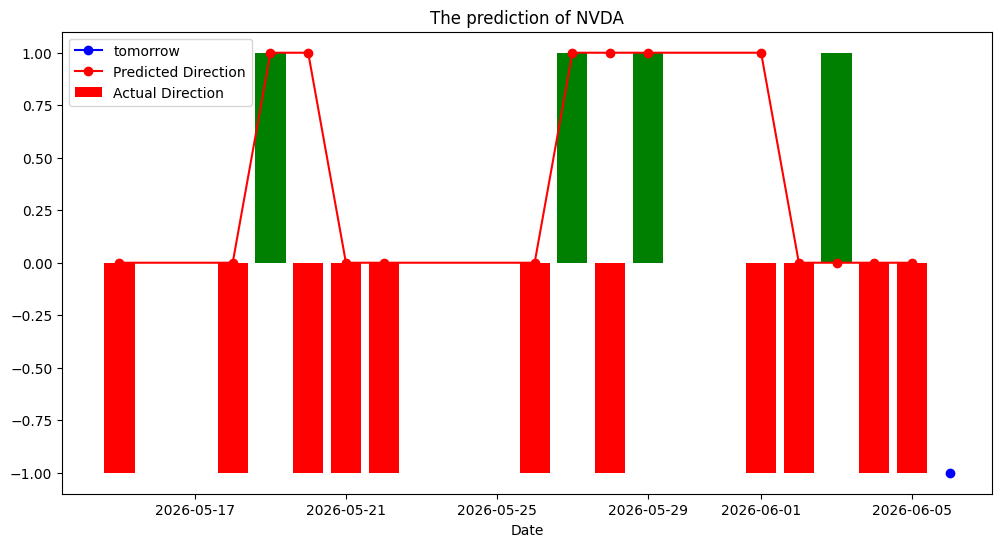

In [44]:
last_n = 15
dates = y_test.index[-last_n:]
actual_direction = actual_direction[-last_n:]   
predicted_direction = predicted_direction[-last_n:]

colors = ['green' if test == 1 else 'red' for test in actual_direction]

next_date = dates[-1] + pd.DateOffset(days = 1)
next_direction = predicted_direction[-1]

plt.figure(figsize=(12,6))

plt.bar(dates,[1 if direction == 1 else -1 for direction in actual_direction], color=colors, label='Actual Direction')

plt.plot(next_date, [1 if next == 1 else -1], color = 'blue', label = 'tomorrow', marker = 'o')

plt.plot(dates, predicted_direction, color='red', label='Predicted Direction', marker='o')

plt.title(f'The prediction of {Stock}')

plt.legend()

plt.xlabel('Date')

plt.show()


